ACTUAL ASSESSMENT CONTAINED ONLY WITHIN BORDERS

In [ ]:
CHOOSE THE RASTER ON WHICH TO PERFORM THE ANALYSIS. IS A VECTOR

In [ ]:
WHAT IS INPUT TO SECTION (just classification vector?)

In [ ]:
CHECK WHICH PARTS OF WESTMINSTER OUTPUT SHOULD BE GIVEN HERE AND WHICH IN NEXT SECTION

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

In [4]:
# Modules
import sys, os

sys.path.append(os.path.abspath('..'))

import src.assessment_utils as assessment_utils
import params

# 6. Accuracy Assessment

The next step is to assess the accuracy of the cover by comparing it to some ground truth. The [data used to train the model](./01_data_acquisition_and_preparation.ipynb#2.1.2-Labelling-Rasters-with-the-ThRasE-Plugin) cannot be used as a true accuracy assessment for two reasons:

1. The model is biased towards the data it is trained on. It is not a reliable metric for assessing true model performance.
2. The labelled data used previously is not randomly sampled. Therefore, it is geographically biased.

The GLA methodology (§3.1 & Appendix 7) details the creation of randomly sampled points for accuracy assessment. The points are randomly generated and then [manually labelled](#6.1-Labelling-Data-for-Accuracy-Assessment).

Once labelled, the points are compared to the green cover to assess its accuracy in [ASSESSMENT SECTION](x.x). The points are also used to generate an independent estimate of the green and canopy covers in [ITREE SECTION](x.x).

* **Tip**: Ensure that all the data used in the project shares the same projection. The metrics would not compute correctly otherwise.



## 6.1 Labelling Data for Accuracy Assessment

### 6.1.1 Point Labelling Process
not the same as 2.1
explain how the points are made
Take script from beginning of next section, which takes points and outputs excel 
print the excel. 
make script in utils

The first step is to estimate the number of points required for labelling. The GLA method (§3.1) labelled a total of 4000 points for the area of Greater London (157,200 hectares or 1,572 km$^2$). Each point is labelled as one of seven categories:

| Code | Description 
| :--- | :--- 
| 0 | Tree
| 1 | Vegetation that is not tree
| 2 | Bare ground
| 3 | Vegetation but unsure whether tree
| 4 | Manmade
| 5 | Unsure
| 6 | Water

----
* **Points required for the City of Westminster**

The area of the City of Westminster is 2203.8 hectares (GLA method Table 5), which is roughly 1.3% of the area of Greater London. If that fraction were applied to 4000 points, then 50 points would be enough. Despite this, it is recommended that no less than 100 points are labelled for each cover class (Canopy, Green, and Neither). Therefore, 300+ points should be labelled. 500 was chosen to [minimise error margins](x.x). 

----

Once the number of points to be labelled is decided, the following steps are applied in QGIS for the generation and labelling of points:

1. Generate the desired number of random points within the area boundaries with the `Random points in layer bounds` tool.
2. For the points layer, create a new integer feature called `landuse_label`.
3. From the "attribute form" of the points layer, change the widget type of `landuse_label` to "Value Map". This allows integer values to be mapped to text.
4. Map the values 0-6 to the seven labels of the above table. An eighth value, 'Unlabelled', may be added as a placeholder value. This helps with keeping track of unlabelled points.
5. From the "Identify Features" panel -> Identify settings -> toggle "Auto open form for single feature identify". This allows a point to be labelled on the canvas simply by clicking on it.
6. Optionally, the point data may be colour-coded by changing the symbology to "Categorised". Differentiating labels through colour increases interpretability. 
8. Use underlying layers to label the points.

<center>
  <figure>
    <img src="../images/point-labelling-process.png" alt="Labelling points with value maps" width="50%">
    <figcaption><i>Labelling points with value maps</i></figcaption>
  </figure>
</center>

It is important to note that the GLA's method permits labellers to use only the data on which the Machine Learning model was trained for labelling points. While such a restriction complicates the labelling process, it is crucial for fair model assessment. If higher-resolution data were referenced, points may label objects that the model does not see.

The output may look something like the following image:

<center>
  <figure>
    <img src="../images/points-labelled-over-map.png" alt="Points labelled over the City of Westminster" width="60%">
    <figcaption><i>Points labelled over the City of Westminster</i></figcaption>
  </figure>
</center>

* **Note**: The GLA method (Appendix 7) utilises a web service with ArcGIS for collaboration on labelling. Depending on the number of points to be labelled, such an approach may be unnecessary.


In [160]:
print(f"The validation points file must be stored stored at: {params.validation_points_file()}")

The validation points file must be stored stored at: ..\data\westminster_data\03_accuracy_assessment_and_result_analysis\validation_points.gpkg


### 6.1.2 Sampling Cover Values

The next step for the validation points layer is sampling ML model classification values from the green cover in [5.3 Improving Cover with Vector Data](./02_model_training_and_postprocessing.ipynb#5.3-Improving-Cover-with-Vector-Data). The function `assessment_utils.sample_vectors_to_points()` is used to apply the green cover values onto the validation points. The sampled validation points layer will contain two columns.

1. `landuse_label`: The manual label at that point (ground truth). 
2. `model_predictions`: the model's prediction at that point.

This combination allows direct comparison of the model's predictions to a ground truth. Unlike the [labelled tiles](./01_data_acquisition_and_preparation.ipynb#2.1.2-Labelling-Rasters-with-the-ThRasE-Plugin), this ground truth is not seen by the ML model. 

In [120]:
print(f"The sampled validation points file is saved to: {params.sampled_validation_points_file(is_output=True)}")

The sampled validation points file is saved to: ..\data\user_data\03_accuracy_assessment_and_result_analysis\sampled_validation_points.gpkg


In [123]:
# --- 1. Define parameters ---

validation_points = params.validation_points_file()
sampled_validation_points = params.sampled_validation_points_file(is_output=True)

canopy_dir = params.vectorised_canopy_cover_folder()
green_dir = params.enhanced_green_cover_folder()

# The name of the new column for sampled cover values. It is recommended to follow the project's naming convention for comprehensibility.
model_pred_column='model_predictions'

In [124]:
# --- 2. Perform sampling ---

sampled_points = assessment_utils.sample_vectors_to_points(
    points_path=validation_points,
    canopy_vector_dir=canopy_dir,
    green_vector_dir=green_dir,
    samples_column=model_pred_column,
    output_path=sampled_validation_points
)

Sampled points successfully saved to: ..\data\westminster_data\03_accuracy_assessment_and_result_analysis\sampled_validation_points.gpkg


In [125]:
# --- 3. Preview sampled points ---
sampled_points.head(5)

,landuse_label,geometry,model_predictions
0,4,POINT (527040.135 180313.785),3
1,4,POINT (528199.306 183289.801),3
2,4,POINT (529221.883 178239.76),3
3,1,POINT (528079.497 183199.984),2
4,4,POINT (525886.751 181641.447),3


## 6.2 Assessing Cover Accuracy

The sampled validation points computed previously can assess the cover accuracy in two ways:
1. Comparing model classification with manual labels using a **Confusion Matrix** (Table 1).
2. Computing accuracy metrics, such as **Producer & Consumer Accuracies** (Table 2).

The processes are adapted from Table 1 and Table 2 of the GLA methodology, respectively.

### 6.2.1 Confusion Matrix

The function `assessment_utils.get_confusion_matrix_csv()` uses the sampled validation points to compute the Confusion Matrix. 

In [126]:
print(f"The Confusion Matrix is saved to: {params.confusion_matrix_table(is_output=True)}")

The Confusion Matrix is saved to: ..\data\user_data\03_accuracy_assessment_and_result_analysis\confusion_matrix_table.csv


In [141]:
# --- 1. Define index-description mappings ---

# Tip: As long as the sampled validation points were created as outlined, no settings need to be changed.

# Manual Labels
manual_names = {
    0: 'Tree', 
    1: 'Vegetation (not Tree)', 
    2: 'Bare Ground', 
    3: 'Vegetation (unsure if Tree)', 
    4: 'Manmade', 
    5: 'Unsure', 
    6: 'Water'
}

# Identify which labels represent uncertainty
unsure_labels = [3, 5]

# Model Predictions
model_names = {
    1: 'Tree', 
    2: 'Green', 
    3: 'Neither'
}

label_column='landuse_label'
model_pred_column='model_predictions'

In [144]:
# --- 2. Generate the Confusion Matrix CSV ---

sampled_points = gpd.read_file(params.sampled_validation_points_file())

raw_table_1 = assessment_utils.get_confusion_matrix_csv(
    points_df=sampled_points,
    label_column=label_column,
    pred_column=model_pred_column,
    manual_names=manual_names,
    model_names=model_names,
    unsure_labels=unsure_labels
)

# Save the raw data as a CSV
csv_output_path = params.confusion_matrix_table(is_output=True)
raw_table_1.to_csv(csv_output_path, index=False)
print(f"Table 1 (Confusion Matrix) saved to {csv_output_path}")


Table 1 (Confusion Matrix) saved to ..\data\user_data\03_accuracy_assessment_and_result_analysis\confusion_matrix_table.csv


Optionally, the resulting CSV file can be styled and displayed using `assessment_utils.style_confusion_matrix()`. Green rows indicate correct classifications, red rows indicate incorrect classifications, and yellow rows indicate 'unsure' labels.

In [145]:
# --- 3. Load the CSV and display the styled table ---

confusion_matrix_table = pd.read_csv(params.confusion_matrix_table())

styled_view = assessment_utils.style_confusion_matrix(confusion_matrix_table)

display(styled_view)

Manual Classification,Modelled Classification,Status,Number of Points,Percentage
Manmade,Neither,Match,306,61.2
Vegetation (not Tree),Green,Match,59,11.8
Tree,Tree,Match,55,11.0
Unsure,Neither,Unsure,17,3.4
Water,Neither,Match,15,3.0
Tree,Neither,Error,13,2.6
Vegetation (not Tree),Neither,Error,12,2.4
Vegetation (unsure if Tree),Neither,Unsure,4,0.8
Vegetation (not Tree),Tree,Error,4,0.8
Bare Ground,Green,Match,3,0.6


### 6.2.2 Accuracy Metrics

EXPLAIN WHAT EACH ACCURACY IS

The next step is to compute the three primary accuracies used to assess how well the classification and labels match: 
1. Producer's Accuracy.
2. Consumer's (or User's) Accuracy.
3. Overall Accuracy.

The metrics are computed separately for the canopy and green covers. Canopy is included as part of the green cover.

Two main considerations make the process of computing these metrics unique for this project:

1. **Mapping manual labels to model classes**:
   
   The model has 3 possible outputs, while the manual labels contain a list of seven values. It must be decided what each of the maps considers as a "positive class" (binary 1) and a "negative class" (binary 0).
    In the case of this project, canopy cover has tree from manual and tree from as positive classes, while green cover has tree and green from manual, and tree vegetation not tree bare ground vegetation unsure if tree as positive classes. 
   
3. **Treating 'unsure' labels**:

   There are two ways to treat unsure labels. The first is worst case where every unsure label is treated as wrong. This unrealistic. The realistic scenario where "it is assumed that half the pixels classified as ‘Unsure’ are modelled correctly in the green cover map, and half the pixels classified as ‘Vegetation (unsure if Tree)’ are modelled correctly in the canopy cover map"
   


In [146]:
print(f"Accuracy Metrics are saved to: {params.accuracy_metrics_table(is_output=True)}")

Accuracy Metrics are saved to: ..\data\user_data\03_accuracy_assessment_and_result_analysis\accuracy_metrics_table.csv


In [147]:
# --- 1. Define the rules for binary evaluation ---

# Tip: As long as the sampled validation points were created as outlined, no settings need to be changed.

# The indices must follow those specified in the `manual_names` & `model_names` dictionaries prior.

table_2_config = {
    'Canopy Map': {
        'Positive Option': 'Tree canopy', 
        'Negative Option': 'Not tree',    
        'Manual Positives': [0],          # Labels as binary 1
        'Model Positives': [1],           # Model predictions as binary 1
        'Forced Error Labels': [3, 5],    # Labels to be adjusted for the worst-case scenario
        'Adjustment Label': 3             # Labels to be adjusted for the realistic scenario
    },
    'Green Cover Map': {
        'Positive Option': 'Green cover',
        'Negative Option': 'Not green',
        'Manual Positives': [0, 1, 2, 3], 
        'Model Positives': [1, 2],        
        'Forced Error Labels': [5],       
        'Adjustment Label': 5             
    }
}

In [158]:
# --- 2. Generate the Accuracy Metrics CSV ---

sampled_points = gpd.read_file(params.sampled_validation_points_file())










# sampled_points = gpd.read_file("E:/london-green-cover/vector-and-csv-data/labelled-classified-points.gpkg")






raw_table_2 = assessment_utils.get_accuracy_metrics_csv(
    points_df=sampled_points,
    label_column=label_column,
    pred_column=model_pred_column,
    config=table_2_config
)

# 3. Save to CSV 
csv_output_path = params.accuracy_metrics_table(is_output=True)
raw_table_2.to_csv(csv_output_path, index=False)
print(f"Table 2 (Accuracy Metrics) saved to {csv_output_path} ")

Table 2 (Accuracy Metrics) saved to ..\data\user_data\03_accuracy_assessment_and_result_analysis\accuracy_metrics_table.csv 


In [161]:
# --- 3. Load the CSV and display the styled table ---

accuracy_metrics_table = pd.read_csv(params.accuracy_metrics_table())

styled_table_2 = assessment_utils.style_accuracy_metrics(accuracy_metrics_table)
display(styled_table_2)

## 6.3 Computing Cover Percentages and Error Margins

* **Note**: All processes so far have worked with the **Minimum Bounding Box (MBB)** of the desired area. While working with the MBB is computationally convenient because of its rectangular shape, it may not represent the desired cover area. Therefore, the border of the desired area is used.

### 6.3.1 Cover Percentages

Once the vectorised green and canopy covers are processed (see [5.3 Improving Cover with Vector Data](./02_model_training_and_postprocessing.ipynb#5.3-Improving-Cover-with-Vector-Data), they may be used to assess the cover percentage over the desired area. The function `assessment_utils.evaluate_final_cover_and_errors()` computes the cover percentages of both the canopy and green covers, alongside the errors.

### 6.3.2 Cover Errors

The next step is to calculate the **Standard Error (SE)** for the green and canopy covers. These values represent the uncertainty in the cover percentages found. Generally speaking, the larger the total study area, the less uncertainty there is, and the smaller the error margins are. The function `assessment_utils.evaluate_final_cover_and_errors()` computes the SE by comparing the vectorised covers to the [testing portions](./02_model_training_and_postprocessing.ipynb#3.1-Splitting-Data-into-Testing-and-Training-Sets) of the labelled tiles.

* **Technical Note**: While the terms for **Error Margins** and **Standard Error** are used interchangeably in this project, it is more precise to say that multiplying the Standard Error by a factor will produce Error Margins within some confidence interval. If the Standard Error is multiplied by a factor of 1.96, there is a 95% confidence in the Error Margins. The GLA method asserts that it computes the Error Margins, but the Standard Error is reported without multiplication.

The following formula is used to compute the Standard Error:

$$SE = |F| + \frac{\sigma}{\sqrt{n}}$$

Where:
1. 'F' is the **Mean Absolute Error**. The absolute error between the prediction and a given patch of labelled data is the difference in classification percentages: $Cover\%_{pred} - Cover\%_{tile}$.
3. '$\sigma$' is the **Standard Deviation** of the absolute errors. 
4. 'n' is the **area in number of patches**. It is a division of the total study area by the area of the training subset of a single tile.

----

* **Computation of 'n' for the City of Westminster Project**:

A single tile is 210x210 pixels. Of the 210 rows, 58 are designated for testing. A patch of 58x210 meters is 12180 meters squared, or 1.218 ha. The total area within the borders of the City of Westminster is 2203.8 ha (GLA method Table 5). The value of 'n' is therefore $2203.8 ha / 1.218 ha = 1809.36$


----


It is important to note the significance of the variable 'n' for the value of the Standard Error. For example, The value for 'n' when classifying all of Greater London with 12.5 hectare patches is 125000 (GLA method Appendix 6), which effectivey erases the Standard Deviation term of the above formula. The larger the classification area, the lower the error margins.


The calculation process is based on the GLA method (§3.3 & Appendix 6). The function `assessment_utils.evaluate_final_cover_and_errors()` plots the **Root Mean Square (RMS)** Error in addition to the Standard Error, following Figure 4 of Appendix 6.

* **Note**: The GLA method (§2.4.2) states that the "raster format is necessary for statistical analysis (i.e., to work out the accuracy of the results)". This project performs error calculations using the enhanced vector files, which are a closer match to the intended output than the unprocessed raster.

<span style="color:red">The note about the GLA mistake</span>


In [38]:
# --- 1. Define necessary paths ---

canopy_cover_vector=Path(params.vectorised_canopy_cover_folder(), "canopy_cover.shp")
enhanced_green_vector=Path(params.enhanced_green_cover_folder(), "green_cover.shp")
area_boundary_vector=params.area_boundary_vector_file()   # is a polygon vector of the study area (not a line vector)
labelled_tiles_folder = params.labelled_tiles_folder()
error_plots = params.error_plot_file(is_output=True)

In [31]:
print(f"The vectorised canopy cover must be stored at: {canopy_cover_vector}")
print(f"\nThe vectorised green cover must be stored at: {enhanced_green_vector}")
print(f"\nThe area boundary must be stored at: {area_boundary_vector}")
print(f"\nThe labelled tiles must be stored at: {labelled_tiles_folder}")

print(f"\nThe error plot is saved to: {error_plots}")

The vectorised canopy cover must be stored at: ..\data\westminster_data\02_model_training_and_postprocessing\green_cover_map\3_vectorised_canopy_cover\canopy_cover.shp

The vectorised green cover must be stored at: ..\data\westminster_data\02_model_training_and_postprocessing\green_cover_map\4_enhanced_green_cover\green_cover.shp

The area boundary must be stored at: ..\data\westminster_data\03_accuracy_assessment_and_result_analysis\area_boundary.gpkg

The labelled tiles must be stored at: ..\data\westminster_data\01_data_acquisition_and_preparation\labelled_tiles

The error plot is saved to: ..\data\user_data\03_accuracy_assessment_and_result_analysis\error_plot.png


In [32]:
tile_paths = [f for f in labelled_tiles_folder.iterdir() if f.is_file()]
print("The below tiles are used for error calculations.\nNote: the tiles must be the same as those used to train the ML model.")
tile_paths

The below tiles are used for error calculations.
Note: the tiles must be the same as those used to train the ML model.


[WindowsPath('../data/westminster_data/01_data_acquisition_and_preparation/labelled_tiles/tile-1.tif'),
 WindowsPath('../data/westminster_data/01_data_acquisition_and_preparation/labelled_tiles/tile-2.tif'),
 WindowsPath('../data/westminster_data/01_data_acquisition_and_preparation/labelled_tiles/tile-3.tif'),
 WindowsPath('../data/westminster_data/01_data_acquisition_and_preparation/labelled_tiles/tile-4.tif'),
 WindowsPath('../data/westminster_data/01_data_acquisition_and_preparation/labelled_tiles/tile-5.tif')]

In [33]:
# --- 2. Define the test window ---

# --- WARNING: ---
# The input variables must be the same as those used in section 3.1 (Splitting Data into Testing and Training Sets ). 

# Returns a Rasterio Window of the testing subset: Window(column offset, row offset, width, height)

TILE_HEIGHT = 210
TILE_WIDTH = 210
TRAIN_RATIO = 0.7
TEST_GAP_PX = 5

test_window = assessment_utils.get_spatial_test_window(
    tile_height=TILE_HEIGHT, tile_width=TILE_WIDTH, 
    train_ratio=TRAIN_RATIO, test_gap_px=TEST_GAP_PX
)

Returned Rasterio object: Window(0, 152, 210, 58) 


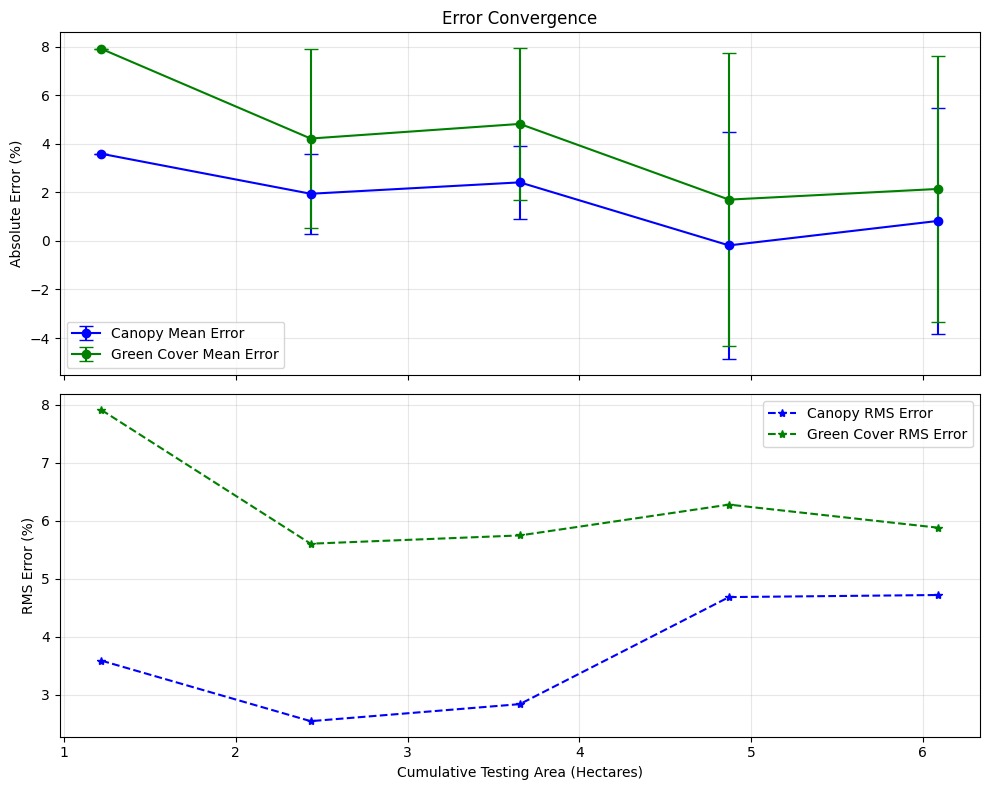

--- FINAL URBAN GREENING REPORT ---
Total Evaluated Area: 2203.0 Hectares

Canopy Cover: 14.90% ± 0.934%
Green Cover:  25.77% ± 2.269%


In [37]:
# --- 3. Calculate cover percentage and error ---
results = assessment_utils.evaluate_final_cover_and_errors(
    canopy_vector_path=canopy_cover_vector,
    green_vector_path=enhanced_green_vector,
    boundary_vector_path=area_boundary_vector,
    labelled_tiles=tile_paths,
    plot_output_path=error_plots,
    testing_window=test_window
)

# --- 4. Display results ---
print(f"--- FINAL URBAN GREENING REPORT ---")
print(f"Total Evaluated Area: {results['Total Area (Ha)']:.1f} Hectares\n")
print(f"Canopy Cover: {results['Canopy Cover']:.2f}% ± {results['Canopy SE']:.3f}%")
print(f"Green Cover:  {results['Green Cover']:.2f}% ± {results['Green SE']:.3f}%")

## 6.4 Independent Cover Estimate Using iTree Method

The cover percentage and margins found in [section 6.3](#6.3-Computing-Cover-Percentages-and-Error-Margins) were based on the ML model's classification. The previously computed values may be verified by computing a completely independent cover estimate based on the labelled [validation points](#6.1.1-Point-Labelling-Process).

The GLA method (§3.4) details the iTree methodology used to compute the independent estimate and the error margin. The function `assessment_utils.calculate_itree_cover()` aggregates the labelled points according to the iTree method for cover estimation. The function prints the aggregation process in detail. The cover error is also computed using the following equation:
$$SE = \sqrt{\frac{p*q}{N}}$$

Where 
* N: total number of sampled points
* p: proportion of points classified as tree/vegetation
* q: proportion of points not classified as tree/vegetation

The points counted as canopy and vegetation are detailed in the output of `assessment_utils.calculate_itree_cover()`.

In [5]:
# 1. Load points
points_gdf = gpd.read_file(params.sampled_validation_points_file())

# 2. Define Manual Labels
manual_names = {
    0: 'Tree', 
    1: 'Vegetation (not Tree)', 
    2: 'Bare Ground', 
    3: 'Vegetation (unsure if Tree)', 
    4: 'Manmade', 
    5: 'Unsure', 
    6: 'Water'
}

# 3. Execute Analysis
# Toggle verbose=True for full calculation 
itree_estimates = assessment_utils.calculate_itree_cover(
    points_df=points_gdf, 
    label_col='landuse_label', 
    manual_names=manual_names,
    verbose=True 
)

--- RAW LABEL PERCENTAGES ---
                             Raw Percentage (%)
Manmade                                    61.6
Vegetation (not Tree)                      15.0
Tree                                       13.8
Unsure                                      4.0
Water                                       3.0
Vegetation (unsure if Tree)                 1.6
Bare Ground                                 1.0


--- CANOPY COVER ESTIMATE ---
Step A: Find tree proportion in known vegetation
Total known vegetation = 13.80% (Tree) + 15.00% (Veg not Tree) = 28.80%
Proportion = 13.80 / 28.80 = 0.4792

Step B: Estimate hidden trees
Estimated hidden trees = 1.60% (Veg unsure if Tree) * 0.4792 = 0.77%

Step C: Final Canopy Cover
Final Canopy = 13.80% + 0.77% = 14.57%
----------------------------------------

--- GREEN COVER ESTIMATE ---
Step A: Sum all confirmed green points
Known Green = 1.00% + 13.80% + 15.00% + 1.60% = 31.40%

Step B: Find green proportion in the known sample
Known sample s

In [11]:
print(f"Canopy Cover Estimate: {itree_estimates['iTree Canopy Cover (%)']: .2f}% ± {itree_estimates['iTree Canopy SE (%)']: .2f}%")
print(f"Canopy Cover Estimate: {itree_estimates['iTree Green Cover (%)']: .2f}% ± {itree_estimates['iTree Green SE (%)']: .2f}%")

Canopy Cover Estimate:  14.57% ±  1.58%
Canopy Cover Estimate:  32.71% ±  2.10%



* **Validating the Process through the GLA Data**

Below is the process applied to the GLA methodology's validation points (Appendix 7). The canopy cover estimate of $19.9 ± 0.63 \%$ and the green cover estimate of $53.1 ± 0.8 \%$ match those reported by the GLA (§3.4).


In [15]:
assessment_utils.print_gla_itree_calculations()


--- RAW LABEL PERCENTAGES ---
                             Raw Percentage (%)
Manmade                                   44.03
Vegetation (not Tree)                     29.38
Tree                                      19.43
Bare Ground                                2.50
Water                                      2.38
Vegetation (unsure if Tree)                1.25
Unsure                                     1.05


--- CANOPY COVER ESTIMATE ---
Step A: Find tree proportion in known vegetation
Total known vegetation = 19.43% (Tree) + 29.38% (Veg not Tree) = 48.80%
Proportion = 19.43 / 48.80 = 0.3981

Step B: Estimate hidden trees
Estimated hidden trees = 1.25% (Veg unsure if Tree) * 0.3981 = 0.50%

Step C: Final Canopy Cover
Final Canopy = 19.43% + 0.50% = 19.92%
----------------------------------------

--- GREEN COVER ESTIMATE ---
Step A: Sum all confirmed green points
Known Green = 2.50% + 19.43% + 29.38% + 1.25% = 52.55%

Step B: Find green proportion in the known sample
Known sample 

# 7. Method Results

This part explains all the accuracy assessment things related to how the city of westminster performed. Compare it to GLA, give reasonings, compare to . This section should be like a standalone read on both ow the method performs well and why the city of westiminster classification is the way it is. 

show map similarities, where it excels where it does not

* Low tree producer accuracy: "If it is true in real life, how likely is it to be true on the map?" 59% suggests that trees are not being captured enough, which is expected. But 89% consumer accuracy shows that tree classifications are trustworthy. A similar idea with green. It proves while the model does underclassify, it is much less likely to misclassify. Note that consumer and producer accuracy are the worst case scenarios.